In [ ]:
import pandas as pd
df= pd.read_csv('/content/cleaned_dataset (2).csv')

In [ ]:
df.head()

,Service Unit,Bill Unit,Pay Unit,Bill Rate,Pay Rate,Payroll OTUnits,Payroll UnitsWithoutOT,Payroll OTAmount,Payroll RegAmount,Total Payroll Amount,Gender,Age,Marital Status,Race,IsCaregiverTerminated,CaregiverAgeAtJoining,Caregiver Attributes_Can do Nights,Caregiver Attributes_Can do Days
0,Caregiver Training,Hourly,Hourly,35.0,0.0,0.0,3.93,0.0,0.0,0.0,Male,53,Married,Asian Canadian,0,42,0,1
1,Personal Care,Hourly,Hourly,36.0,22.5,0.0,4.00,0.0,90.0,90.0,Female,52,Unknown,British Canadian,1,46,1,1
2,Personal Care,Hourly,Hourly,34.0,22.0,0.0,6.00,0.0,132.0,132.0,Female,52,Unknown,British Canadian,1,46,1,1
3,Personal Care,Hourly,Hourly,41.0,18.0,0.0,12.00,0.0,216.0,216.0,Female,55,Single,Middle Eastern Canadian,1,50,0,1
4,RPNRN Shift,Hourly,Hourly,60.0,40.0,0.0,2.00,0.0,80.0,80.0,Female,60,Married,Middle Eastern Canadian,1,50,1,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Service Unit                        1000 non-null   object 
 1   Bill Unit                           1000 non-null   object 
 2   Pay Unit                            1000 non-null   object 
 3   Bill Rate                           1000 non-null   float64
 4   Pay Rate                            1000 non-null   float64
 5   Payroll OTUnits                     1000 non-null   float64
 6   Payroll UnitsWithoutOT              1000 non-null   float64
 7   Payroll OTAmount                    1000 non-null   float64
 8   Payroll RegAmount                   1000 non-null   float64
 9   Total Payroll Amount                1000 non-null   float64
 10  Gender                              1000 non-null   object 
 11  Age                                 1000 non

In [ ]:
df.drop(columns=['Bill Unit','Bill Rate','Payroll OTUnits', 'Payroll RegAmount'],inplace= True)

##Final columns extracted after cleaning and eda

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Service Unit                        1000 non-null   object 
 1   Pay Unit                            1000 non-null   object 
 2   Pay Rate                            1000 non-null   float64
 3   Payroll UnitsWithoutOT              1000 non-null   float64
 4   Payroll OTAmount                    1000 non-null   float64
 5   Total Payroll Amount                1000 non-null   float64
 6   Gender                              1000 non-null   object 
 7   Age                                 1000 non-null   int64  
 8   Marital Status                      1000 non-null   object 
 9   Race                                1000 non-null   object 
 10  IsCaregiverTerminated               1000 non-null   int64  
 11  CaregiverAgeAtJoining               1000 non

In [ ]:
df.head()

,Service Unit,Pay Unit,Pay Rate,Payroll UnitsWithoutOT,Payroll OTAmount,Total Payroll Amount,Gender,Age,Marital Status,Race,IsCaregiverTerminated,CaregiverAgeAtJoining,Caregiver Attributes_Can do Nights,Caregiver Attributes_Can do Days
0,Caregiver Training,Hourly,0.0,3.93,0.0,0.0,Male,53,Married,Asian Canadian,0,42,0,1
1,Personal Care,Hourly,22.5,4.00,0.0,90.0,Female,52,Unknown,British Canadian,1,46,1,1
2,Personal Care,Hourly,22.0,6.00,0.0,132.0,Female,52,Unknown,British Canadian,1,46,1,1
3,Personal Care,Hourly,18.0,12.00,0.0,216.0,Female,55,Single,Middle Eastern Canadian,1,50,0,1
4,RPNRN Shift,Hourly,40.0,2.00,0.0,80.0,Female,60,Married,Middle Eastern Canadian,1,50,1,1


##Encoding categorical cols and Correlation between all the cols


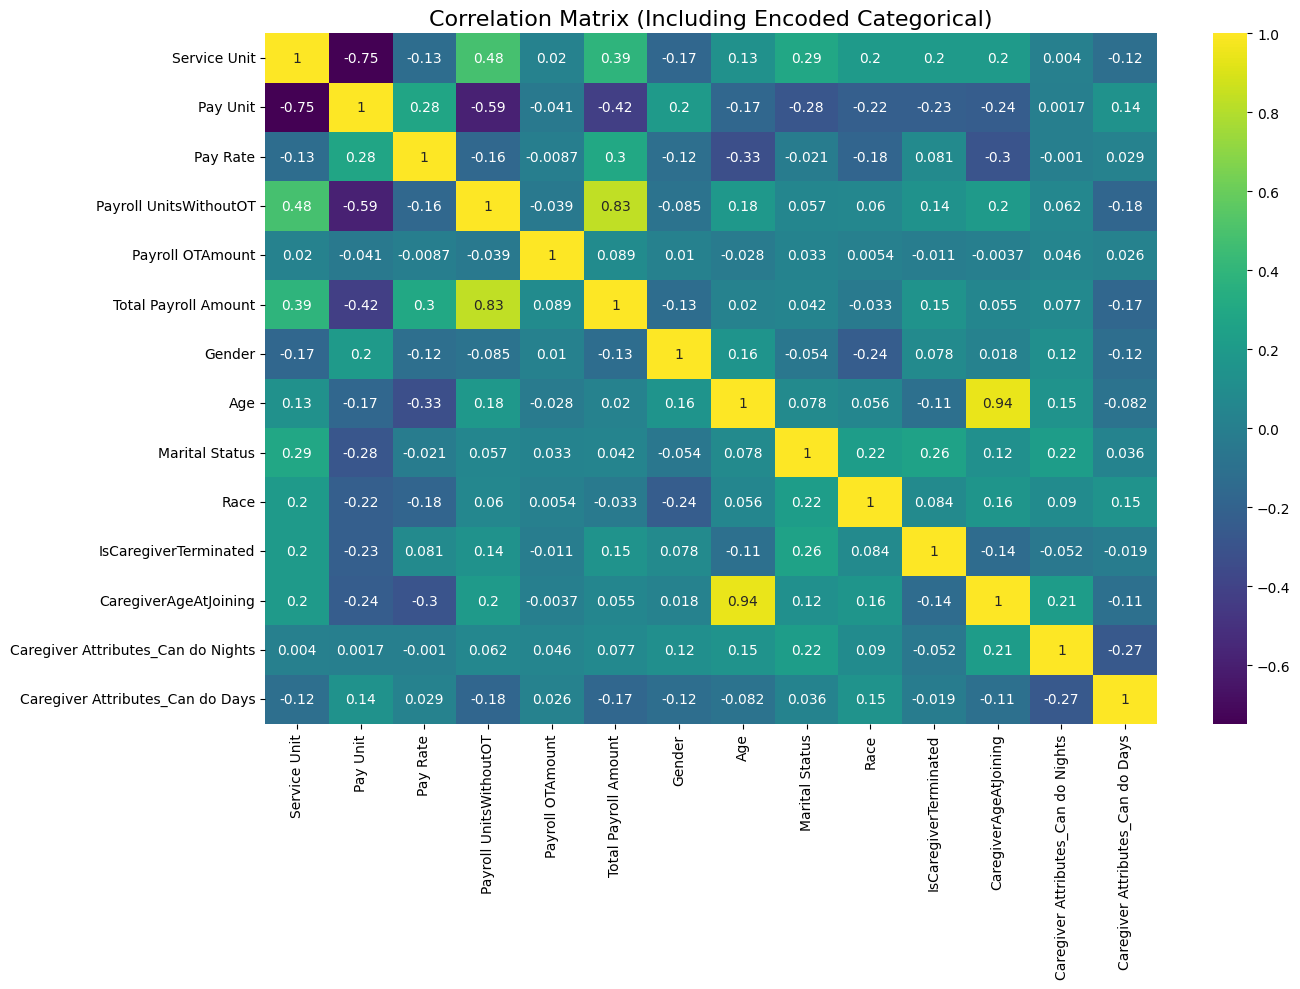

In [ ]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include='number').columns
categorical_cols = df.select_dtypes(exclude='number').columns
df_encoded = df.copy()
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])

# New correlation heatmap including categorical
plt.figure(figsize=(14, 10))
sns.heatmap(df_encoded.corr(), annot=True, cmap='viridis')
plt.title("Correlation Matrix (Including Encoded Categorical)", fontsize=16)
plt.tight_layout()
plt.show()

##Get most important features from random forest model

<ipython-input-12-4116309466>:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances_df.head(15), x='Importance', y='Feature', palette='viridis')


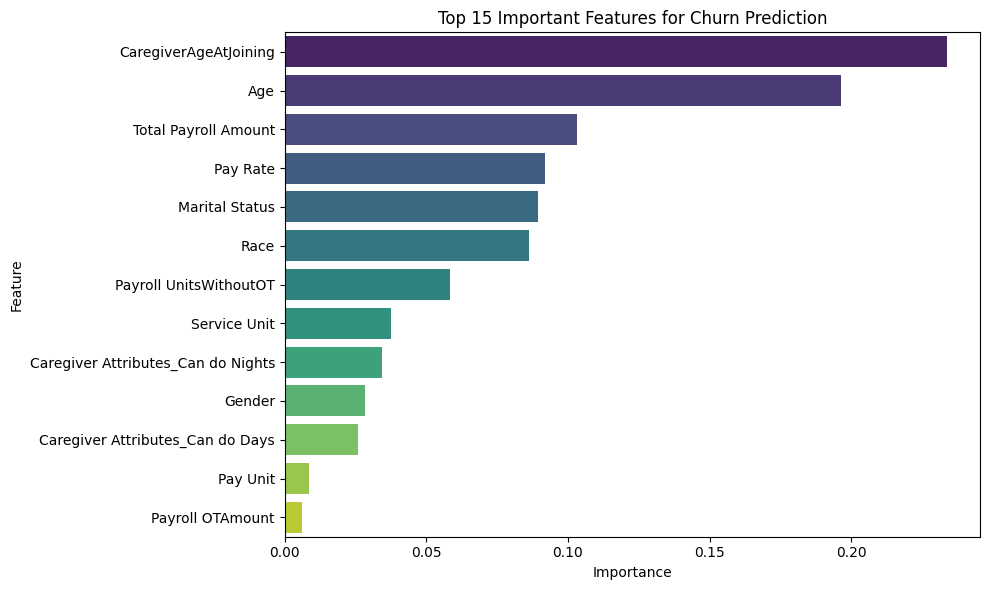

In [ ]:
target = 'IsCaregiverTerminated'
from sklearn.preprocessing import LabelEncoder

# Encode categorical features
categorical_cols = df.select_dtypes(include='object').columns

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

from sklearn.model_selection import train_test_split

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
importances = rf.feature_importances_
features = X.columns

# Create DataFrame of feature importances
importances_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=importances_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title("Top 15 Important Features for Churn Prediction")
plt.tight_layout()
plt.show()

In [ ]:
for cat_col in categorical_cols:
  print(df[cat_col].value_counts())



Service Unit
14    695
6      97
13     58
8      35
19     28
16     17
5      14
0       8
17      7
10      7
15      6
4       6
18      5
3       5
20      3
2       2
12      2
11      1
1       1
7       1
9       1
21      1
Name: count, dtype: int64
Pay Unit
1    832
2    167
0      1
Name: count, dtype: int64
Gender
0    784
1    216
Name: count, dtype: int64
Marital Status
1    621
4    147
0    114
3    111
2      7
Name: count, dtype: int64
Race
9    460
1    179
0    136
6     87
2     52
4     44
3     23
7     13
5      5
8      1
Name: count, dtype: int64


##Encoding with ordinal encoder

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

# Let's say these are your categorical columns
categorical_cols = ['Gender', 'Race', 'Marital Status','Service Unit','Pay Unit']

# Split first
X = df.drop("IsCaregiverTerminated", axis=1)
y = df["IsCaregiverTerminated"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Fit encoder on training set
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train[categorical_cols] = encoder.fit_transform(X_train[categorical_cols])

# Transform test set
X_test[categorical_cols] = encoder.transform(X_test[categorical_cols])


In [ ]:
import joblib

# Save the encoder
joblib.dump(encoder, 'ordinal_encoder.pkl')

# Later, load it again
encoder = joblib.load('ordinal_encoder.pkl')


##Final comparison between top 5 models we chose and got their accuracies

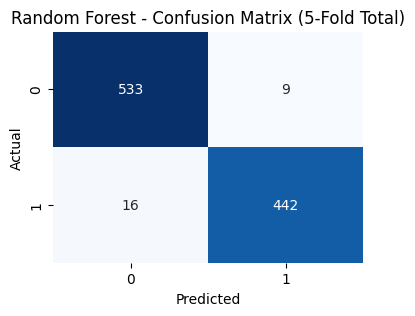


Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       542
           1       0.98      0.97      0.97       458

    accuracy                           0.97      1000
   macro avg       0.98      0.97      0.97      1000
weighted avg       0.98      0.97      0.97      1000



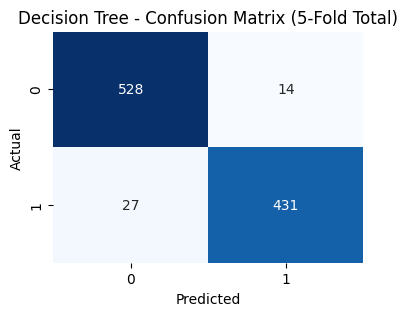


Classification Report for Decision Tree:

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       542
           1       0.97      0.94      0.95       458

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



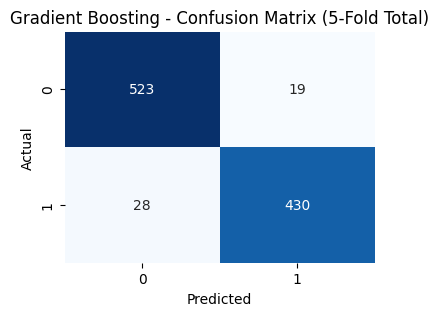


Classification Report for Gradient Boosting:

              precision    recall  f1-score   support

           0       0.95      0.96      0.96       542
           1       0.96      0.94      0.95       458

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:15:14] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:15:15] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:15:15] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:15:15] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:15:16] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

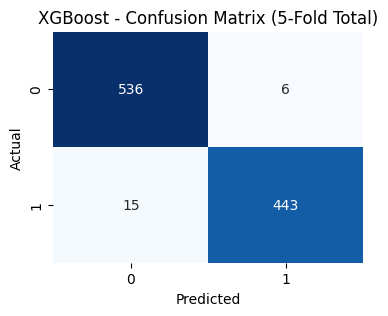


Classification Report for XGBoost:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       542
           1       0.99      0.97      0.98       458

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 367, number of negative: 433
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000416 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 251
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.458750 -> initscore=-0.165376
[LightGBM] [Info] Start training from score -0.165376
[Ligh

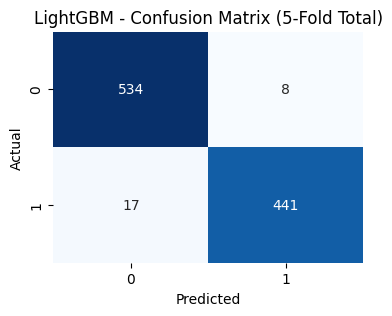


Classification Report for LightGBM:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       542
           1       0.98      0.96      0.97       458

    accuracy                           0.97      1000
   macro avg       0.98      0.97      0.97      1000
weighted avg       0.98      0.97      0.97      1000


Overall Comparison:
               Model  Accuracy  Precision    Recall  F1 Score
3            XGBoost     0.979   0.986490  0.967320  0.976734
4           LightGBM     0.975   0.982218  0.962948  0.972423
0      Random Forest     0.975   0.980018  0.965098  0.972397
1      Decision Tree     0.959   0.968637  0.941113  0.954610
2  Gradient Boosting     0.953   0.957765  0.938987  0.948161


In [ ]:
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define models
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42)
}

# Set up StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def evaluate_model_with_cm_and_report(name, model):
    acc, prec, rec, f1 = [], [], [], []
    cm_total = np.array([[0, 0], [0, 0]])

    # Store all predictions and true labels for final report
    all_y_true = []
    all_y_pred = []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        acc.append(accuracy_score(y_val, y_pred))
        prec.append(precision_score(y_val, y_pred))
        rec.append(recall_score(y_val, y_pred))
        f1.append(f1_score(y_val, y_pred))

        cm = confusion_matrix(y_val, y_pred)
        cm_total += cm

        all_y_true.extend(y_val)
        all_y_pred.extend(y_pred)

    # Confusion matrix plot
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm_total, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{name} - Confusion Matrix (5-Fold Total)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Aggregated classification report
    print(f"\nClassification Report for {name}:\n")
    print(classification_report(all_y_true, all_y_pred, digits=2))

    return {
        'Model': name,
        'Accuracy': np.mean(acc),
        'Precision': np.mean(prec),
        'Recall': np.mean(rec),
        'F1 Score': np.mean(f1)
    }

# Run evaluations
results_cm = [evaluate_model_with_cm_and_report(name, model) for name, model in models.items()]

# Display metrics summary
results_cm_df = pd.DataFrame(results_cm)
print("\nOverall Comparison:")
print(results_cm_df.sort_values(by='F1 Score', ascending=False))


##Based on the overall comparison, it chose the best model and saved its .pkl file

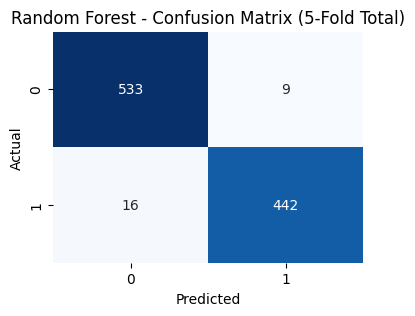


Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       542
           1       0.98      0.97      0.97       458

    accuracy                           0.97      1000
   macro avg       0.98      0.97      0.97      1000
weighted avg       0.98      0.97      0.97      1000



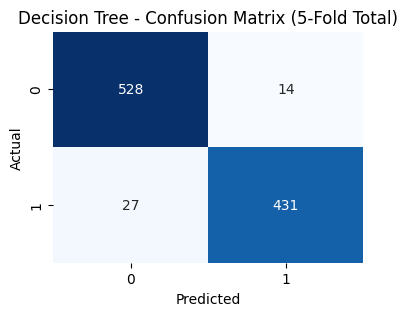


Classification Report for Decision Tree:

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       542
           1       0.97      0.94      0.95       458

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



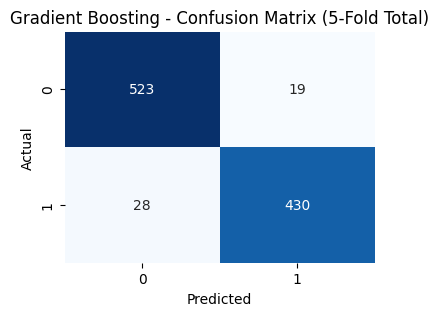


Classification Report for Gradient Boosting:

              precision    recall  f1-score   support

           0       0.95      0.96      0.96       542
           1       0.96      0.94      0.95       458

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:15:35] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:15:35] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:15:36] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:15:36] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:15:36] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

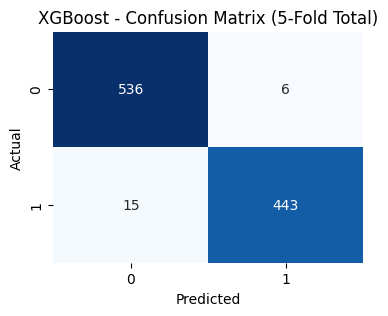


Classification Report for XGBoost:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       542
           1       0.99      0.97      0.98       458

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 367, number of negative: 433
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000157 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 251
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.458750 -> initscore=-0.165376
[LightGBM] [Info] Start training from score -0.165376
[Ligh

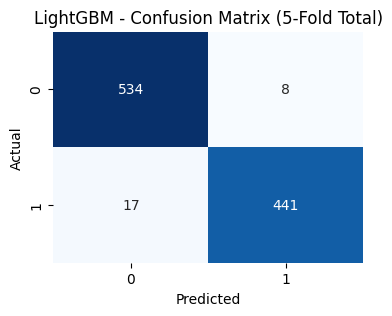


Classification Report for LightGBM:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       542
           1       0.98      0.96      0.97       458

    accuracy                           0.97      1000
   macro avg       0.98      0.97      0.97      1000
weighted avg       0.98      0.97      0.97      1000


Overall Comparison:
               Model  Accuracy  Precision    Recall  F1 Score
3            XGBoost     0.979   0.986490  0.967320  0.976734
4           LightGBM     0.975   0.982218  0.962948  0.972423
0      Random Forest     0.975   0.980018  0.965098  0.972397
1      Decision Tree     0.959   0.968637  0.941113  0.954610
2  Gradient Boosting     0.953   0.957765  0.938987  0.948161

✅ Best Model Based on F1 Score: XGBoost

📦 Model saved as 'xgboost_model.pkl'


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:15:38] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
import joblib

# Evaluate all models
results_cm = []
best_f1 = 0
best_model_name = ""
best_model_instance = None

for name, model in models.items():
    result = evaluate_model_with_cm_and_report(name, model)
    results_cm.append(result)

    if result['F1 Score'] > best_f1:
        best_f1 = result['F1 Score']
        best_model_name = name
        best_model_instance = model

# Results summary
results_cm_df = pd.DataFrame(results_cm)
print("\nOverall Comparison:")
print(results_cm_df.sort_values(by='F1 Score', ascending=False))

# Retrain the best model on full data
print(f"\n✅ Best Model Based on F1 Score: {best_model_name}")
best_model_instance.fit(X, y)

# Save the best model
joblib.dump(best_model_instance, f"{best_model_name.replace(' ', '_').lower()}_model.pkl")
print(f"\n📦 Model saved as '{best_model_name.replace(' ', '_').lower()}_model.pkl'")


#Save Model trained on actual df


In [ ]:
# STEP 1: TRAIN AND SAVE MODEL

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# Use actual dataset
X = df.drop(columns=["IsCaregiverTerminated"])
y = df["IsCaregiverTerminated"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Identify categorical and numerical columns
categorical = X.select_dtypes(include=["object","category"]).columns.tolist()
numerical = X.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()

# Preprocessing + XGBoost pipeline
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('num', StandardScaler(), numerical)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

# Fit model
pipeline.fit(X_train, y_train)

# Evaluate on test split
y_pred_test = pipeline.predict(X_test)
print("✅ Test Accuracy (from df):", accuracy_score(y_test, y_pred_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))

 # Save model
joblib.dump(pipeline, "xgboost_model_final.pkl")


✅ Test Accuracy (from df): 0.965

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97       121
           1       0.96      0.95      0.96        79

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200

Confusion Matrix:
 [[118   3]
 [  4  75]]


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:15:56] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


['xgboost_model_final.pkl']

##SHUFFLED DATA (shuffled_df)


In [ ]:
import pandas as pd
import joblib
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from io import StringIO

# Replace with your actual CSV strings
csv1 = """Service Unit,Pay Unit,Pay Rate,Payroll UnitsWithoutOT,Payroll OTAmount,Total Payroll Amount,Gender,Age,Marital Status,Race,IsCaregiverTerminated,Caregiver Attributes_Can do Nights,Caregiver Attributes_Can do Days,CaregiverTenureYears
Personal Care,Hourly,0.0000,4.1973,0.0,0.0000,Female,37.8318,Divorce,Hispanic or Latino Canadian,0,1,1,3.1649
HMAP INCL,Visit,0.0000,1.0704,0.0,0.0000,Male,50.0137,Married,Asian Canadian,0,0,1,10.2478
Personal Care,Hourly,22.2040,3.8109,0.0,80.4711,Female,53.4947,Unknown,Middle Eastern Canadian,0,1,1,4.1010
Personal Care,Hourly,21.9041,10.9806,0.0,219.0307,Female,59.5024,Married,Asian Canadian,0,0,1,6.6723
Personal Care,Hourly,19.7685,3.8934,0.0,90.5353,Female,46.3464,Divorce,Eastern European Canadian,0,0,1,3.0784
Personal Care,Hourly,20.1002,5.2438,0.0,97.6920,Female,47.7322,Unknown,Middle Eastern Canadian,0,1,1,3.3166
HMAP INCL,Visit,0.0000,1.0049,0.0,0.0000,Female,47.7430,Married,South Asian Canadian,0,1,1,2.9382
Personal Care,Hourly,22.5678,5.1124,0.0,112.4027,Female,61.1134,Unknown,Middle Eastern Canadian,0,0,1,3.2069
Personal Care,Hourly,21.5607,5.6836,0.0,121.0505,Female,51.6553,Unknown,Eastern European Canadian,0,1,1,3.4827
Palliative,Hourly,21.4562,3.9272,0.0,84.2933,Female,44.6834,Married,Hispanic or Latino Canadian,0,1,1,2.8873
Personal Care,Hourly,20.9846,5.2093,0.0,109.2823,Female,51.2358,Married,Hispanic or Latino Canadian,0,0,1,2.8897
Personal Care,Hourly,21.2143,3.9567,0.0,88.0621,Female,41.8907,Divorce,Middle Eastern Canadian,0,1,1,3.2604
HMAP INCL,Visit,0.0000,1.0114,0.0,0.0000,Female,50.8832,Married,Eastern European Canadian,0,1,1,2.9976
Personal Care,Hourly,22.1012,4.0029,0.0,88.8439,Female,52.3089,Married,Eastern European Canadian,0,0,1,3.1381
Personal Care,Hourly,21.8888,4.1075,0.0,90.3950,Female,46.4108,Unknown,Asian Canadian,0,1,1,3.1689
Personal Care,Hourly,21.7020,5.8920,0.0,126.8044,Female,60.9931,Unknown,Middle Eastern Canadian,0,0,1,2.8023
Personal Care,Hourly,21.3249,4.1057,0.0,91.2958,Female,56.4702,Married,Hispanic or Latino Canadian,0,1,1,3.1734
HMAP INCL,Visit,0.0000,1.0938,0.0,0.0000,Male,50.0634,Married,Middle Eastern Canadian,0,0,1,2.8575
Personal Care,Hourly,20.8952,3.9006,0.0,84.7411,Female,51.9040,Unknown,Eastern European Canadian,0,1,1,3.2387
Personal Care,Hourly,21.4387,4.0687,0.0,87.5523,Female,50.2061,Unknown,Hispanic or Latino Canadian,0,1,1,3.1469
Personal Care,Hourly,22.4981,5.1293,0.0,112.8747,Female,53.7467,Married,Eastern European Canadian,0,0,1,2.9511
Personal Care,Hourly,20.7103,3.7743,0.0,78.3225,Female,47.6116,Unknown,Asian Canadian,0,1,1,2.8972
Personal Care,Hourly,21.8202,3.8002,0.0,82.9304,Female,58.6841,Married,Hispanic or Latino Canadian,0,0,1,3.2874
Personal Care,Hourly,22.2201,5.1329,0.0,113.0983,Female,52.4047,Unknown,Hispanic or Latino Canadian,0,1,1,3.0094
HMAP INCL,Visit,0.0000,1.0135,0.0,0.0000,Female,54.2604,Unknown,Middle Eastern Canadian,0,1,1,2.8726
Personal Care,Hourly,21.8957,4.2845,0.0,93.7702,Female,59.7182,Married,Hispanic or Latino Canadian,0,0,1,3.0052
Personal Care,Hourly,21.8841,5.0613,0.0,110.7084,Female,47.2357,Married,Eastern European Canadian,0,1,1,3.1196
HMAP INCL,Visit,0.0000,1.0009,0.0,0.0000,Female,45.1468,Unknown,Hispanic or Latino Canadian,0,0,1,3.0674
Personal Care,Hourly,21.3027,3.9666,0.0,84.4894,Female,50.1176,Married,Eastern European Canadian,0,1,1,2.9437
Palliative,Hourly,21.7638,3.9542,0.0,86.0725,Female,54.1789,Unknown,South Asian Canadian,0,1,1,2.9610
Personal Care,Hourly,21.9312,4.0011,0.0,87.7459,Female,56.9627,Unknown,Middle Eastern Canadian,0,0,1,3.1328
Personal Care,Hourly,21.6129,4.8935,0.0,105.7857,Female,45.7283,Married,Eastern European Canadian,0,1,1,3.0912
HMAP INCL,Visit,0.0000,1.0012,0.0,0.0000,Female,49.1393,Divorce,Middle Eastern Canadian,0,1,1,3.2268
Personal Care,Hourly,20.7938,4.2386,0.0,88.2902,Female,60.2577,Married,Hispanic or Latino Canadian,0,0,1,2.9314
Personal Care,Hourly,22.2015,5.0034,0.0,111.0502,Female,48.7352,Unknown,Asian Canadian,0,1,1,3.1921
Personal Care,Hourly,21.8704,4.0096,0.0,87.8257,Female,54.9043,Unknown,Hispanic or Latino Canadian,0,1,1,3.2780
Personal Care,Hourly,20.9937,4.1553,0.0,87.4173,Female,46.2285,Married,Eastern European Canadian,0,0,1,3.0501
Personal Care,Hourly,21.7102,5.2893,0.0,114.6755,Female,52.8671,Unknown,Asian Canadian,0,1,1,3.1649
Personal Care,Hourly,21.9570,4.1150,0.0,90.4892,Female,60.3915,Married,Middle Eastern Canadian,0,0,1,3.0750
Personal Care,Hourly,21.8407,5.2884,0.0,115.6768,Female,57.1178,Unknown,Hispanic or Latino Canadian,0,1,1,3.0984
Personal Care,Hourly,22.1283,4.1051,0.0,90.8400,Female,51.9932,Divorce,Eastern European Canadian,0,1,1,3.1126
Personal Care,Hourly,21.7752,4.1763,0.0,90.8513,Female,47.4391,Unknown,Asian Canadian,0,1,1,3.0477
HMAP INCL,Visit,0.0000,1.0031,0.0,0.0000,Female,54.1266,Unknown,Middle Eastern Canadian,0,0,1,3.1145
Personal Care,Hourly,21.3850,4.0021,0.0,85.7150,Female,59.3741,Married,Asian Canadian,0,1,1,3.1024
Personal Care,Hourly,21.6421,4.9024,0.0,106.0821,Female,51.8627,Married,Hispanic or Latino Canadian,0,0,1,3.0431
Personal Care,Hourly,20.9643,3.9026,0.0,82.9421,Female,58.3735,Unknown,Middle Eastern Canadian,0,1,1,3.0009
Palliative,Hourly,21.7802,4.0104,0.0,87.3594,Female,53.6853,Married,Eastern European Canadian,0,1,1,3.0128
Personal Care,Hourly,21.5420,4.3945,0.0,93.8357,Female,55.3861,Divorce,Hispanic or Latino Canadian,0,0,1,2.9813
HMAP INCL,Visit,0.0000,1.0043,0.0,0.0000,Female,58.1065,Married,Middle Eastern Canadian,0,1,1,3.0055
Personal Care,Hourly,21.6102,4.2783,0.0,92.3191,Female,50.4282,Unknown,Hispanic or Latino Canadian,0,0,1,3.0256
Personal Care,Hourly,21.7704,5.0019,0.0,109.1230,Female,45.3476,Married,Eastern European Canadian,0,1,1,3.0971
Personal Care,Hourly,21.8997,3.9423,0.0,86.4792,Female,57.9982,Unknown,Hispanic or Latino Canadian,0,1,1,3.1426
Personal Care,Hourly,21.6849,5.0943,0.0,110.7395,Female,52.8840,Unknown,Middle Eastern Canadian,0,0,1,2.9702
Personal Care,Hourly,21.8481,4.0047,0.0,87.4996,Female,58.1242,Married,Eastern European Canadian,0,1,1,3.0305
Personal Care,Hourly,21.5316,4.8532,0.0,104.5206,Female,53.8203,Unknown,Hispanic or Latino Canadian,0,0,1,3.0779
Personal Care,Hourly,21.9268,3.9582,0.0,86.9410,Female,50.1374,Divorce,Asian Canadian,0,1,1,3.0341
Personal Care,Hourly,21.7014,4.2134,0.0,91.5783,Female,46.3236,Unknown,Eastern European Canadian,0,1,1,3.1006
Personal Care,Hourly,21.9824,4.2972,0.0,94.4496,Female,52.7125,Unknown,Hispanic or Latino Canadian,0,0,1,3.0373
HMAP INCL,Visit,0.0000,1.0065,0.0,0.0000,Female,51.8847,Married,Middle Eastern Canadian,0,1,1,3.0672
Personal Care,Hourly,22.2012,4.3145,0.0,95.7348,Female,56.1127,Unknown,Hispanic or Latino Canadian,0,1,1,3.0035
Personal Care,Hourly,21.7835,4.3029,0.0,94.7272,Female,50.4161,Married,Eastern European Canadian,0,0,1,3.0596
Personal Care,Hourly,21.9617,4.8827,0.0,107.4721,Female,49.2864,Unknown,Asian Canadian,0,1,1,3.0283
Personal Care,Hourly,21.7164,4.0136,0.0,87.1574,Female,53.4921,Married,Hispanic or Latino Canadian,0,1,1,2.9938
Personal Care,Hourly,22.0053,4.1274,0.0,91.1622,Female,60.3829,Unknown,Eastern European Canadian,0,0,1,3.0189
Personal Care,Hourly,22.1891,4.0942,0.0,90.8752,Female,54.1110,Unknown,Hispanic or Latino Canadian,0,1,1,3.1057
Palliative,Hourly,21.7518,3.9134,0.0,85.1027,Female,49.9953,Married,Asian Canadian,0,0,1,3.1444
HMAP INCL,Visit,0.0000,1.0057,0.0,0.0000,Female,52.7775,Married,Eastern European Canadian,0,1,1,3.1112
Personal Care,Hourly,21.8045,4.7821,0.0,104.5664,Female,57.2077,Unknown,Middle Eastern Canadian,0,0,1,2.9992
Personal Care,Hourly,21.6620,4.0037,0.0,86.6758,Female,45.8056,Married,Hispanic or Latino Canadian,0,1,1,3.0210
Personal Care,Hourly,21.9215,4.0015,0.0,87.6348,Female,55.0173,Unknown,Hispanic or Latino Canadian,0,1,1,3.1478
Personal Care,Hourly,21.8861,4.1753,0.0,91.3965,Female,53.1872,Divorce,Eastern European Canadian,0,0,1,3.0814
Personal Care,Hourly,21.6974,4.8902,0.0,106.1168,Female,58.1263,Married,Middle Eastern Canadian,0,1,1,3.0851
HMAP INCL,Visit,0.0000,1.0044,0.0,0.0000,Female,49.3185,Unknown,Middle Eastern Canadian,0,1,1,2.9639
Personal Care,Hourly,22.0342,4.0918,0.0,90.2081,Female,60.3708,Unknown,Asian Canadian,0,0,1,3.0346
Personal Care,Hourly,21.9043,4.2179,0.0,92.2894,Female,52.7812,Unknown,Eastern European Canadian,0,1,1,3.0247
Personal Care,Hourly,21.7735,5.0491,0.0,109.9733,Female,50.6693,Unknown,Hispanic or Latino Canadian,0,1,1,3.0021
Personal Care,Hourly,21.6802,4.1135,0.0,89.2731,Female,48.2068,Married,Middle Eastern Canadian,0,0,1,3.0285
Personal Care,Hourly,22.0176,4.0054,0.0,88.3421,Female,51.6820,Divorce,Middle Eastern Canadian,0,1,1,3.0539
Personal Care,Hourly,21.8652,5.0321,0.0,109.6575,Female,59.3875,Unknown,Eastern European Canadian,0,1,1,3.1092
Personal Care,Hourly,21.9505,4.0173,0.0,88.3782,Female,54.6051,Unknown,Hispanic or Latino Canadian,0,1,1,3.0931
HMAP INCL,Visit,0.0000,1.0094,0.0,0.0000,Female,57.2150,Married,Middle Eastern Canadian,0,0,1,3.0456
Personal Care,Hourly,21.7211,4.2123,0.0,91.5933,Female,55.1920,Unknown,Hispanic or Latino Canadian,0,1,1,3.0484
Personal Care,Hourly,22.0572,5.1133,0.0,112.8549,Female,48.6074,Unknown,Eastern European Canadian,0,0,1,2.9913
Personal Care,Hourly,21.9094,4.0782,0.0,89.7005,Female,47.1325,Unknown,Middle Eastern Canadian,0,1,1,3.0119
Personal Care,Hourly,21.6728,4.3811,0.0,94.0666,Female,53.2049,Unknown,Eastern European Canadian,0,0,1,3.0360
Personal Care,Hourly,21.8429,4.0086,0.0,87.5726,Female,59.5081,Divorce,Middle Eastern Canadian,0,1,1,3.1475
Personal Care,Hourly,21.7603,5.0031,0.0,108.7982,Female,60.4030,Unknown,Hispanic or Latino Canadian,0,1,1,3.0288
Personal Care,Hourly,21.7807,4.1193,0.0,89.6903,Female,49.5720,Unknown,Middle Eastern Canadian,0,0,1,3.0617"""

csv2 = """Service Unit,Pay Unit,Pay Rate,Payroll UnitsWithoutOT,Payroll OTAmount,Total Payroll Amount,Gender,Age,Marital Status,Race,IsCaregiverTerminated,Caregiver Attributes_Can do Nights,Caregiver Attributes_Can do Days,CaregiverTenureYears
Personal Care,Hourly,18.37,5.00,0.0,93.43,Female,42.76,Unknown,Middle Eastern Canadian,1,0,1,5.20
RPNRN Shift,Hourly,28.81,12.62,0.0,380.72,Female,49.67,Married,Middle Eastern Canadian,1,0,1,5.09
Caregiver Training,Hourly,19.95,3.77,0.0,64.98,Female,44.44,Unknown,Asian Canadian,1,1,1,2.03
Personal Care,Hourly,20.34,11.55,0.0,234.26,Female,42.97,Married,Asian Canadian,1,0,1,11.03
Respite Personal Care,Hourly,23.68,3.63,0.0,94.46,Female,47.64,Unknown,British Canadian,1,1,1,6.20
Palliative,Hourly,20.59,10.40,0.0,223.22,Female,47.51,Married,African Canadian,1,1,1,3.87
Personal Care,Hourly,21.18,10.56,0.0,264.55,Male,59.24,Married,Middle Eastern Canadian,1,1,1,4.79
Personal Care,Hourly,20.08,4.06,0.0,86.06,Male,30.51,Single,African Canadian,1,0,0,0.90
Personal Care,Hourly,18.14,4.90,0.0,94.43,Female,41.62,Unknown,Middle Eastern Canadian,1,0,1,5.23
Personal Care,Hourly,18.33,11.07,0.0,230.27,Female,67.62,Married,Asian Canadian,1,0,1,11.78
Foot Care,Visit,37.40,1.04,0.0,56.77,Female,60.71,Married,Middle Eastern Canadian,1,1,1,9.94
Personal Care,Hourly,22.37,11.99,0.0,231.08,Male,55.70,Single,Middle Eastern Canadian,1,1,1,3.23
Personal Care,Hourly,16.25,4.92,0.0,82.40,Female,26.21,Single,Middle Eastern Canadian,1,0,1,4.13
Personal Care,Hourly,21.71,2.90,0.0,77.60,Male,57.88,Single,Middle Eastern Canadian,1,1,1,3.13
Personal Care,Hourly,22.87,3.88,0.0,95.35,Male,55.54,Married,Middle Eastern Canadian,1,1,1,4.80
Personal Care,Hourly,0.00,5.61,0.0,0.00,Female,47.06,Unknown,Middle Eastern Canadian,1,1,1,2.91
Foot Care,Visit,39.31,0.93,0.0,42.62,Female,64.08,Married,Middle Eastern Canadian,1,1,1,9.79
Personal Care,Hourly,20.58,4.02,0.0,78.05,Female,55.93,Unknown,Middle Eastern Canadian,1,1,1,2.99
HMAP INCL,Visit,20.94,0.95,0.0,22.17,Male,54.37,Married,Middle Eastern Canadian,1,1,1,4.69
Post Operative Care,Hourly,20.93,10.59,0.0,234.41,Female,43.36,Married,African Canadian,1,1,0,1.94
Personal Care,Hourly,19.87,3.96,0.0,78.89,Female,49.92,Single,Asian Canadian,1,1,1,4.88
Personal Care,Hourly,19.42,11.02,0.0,226.10,Female,45.38,Married,Hispanic Canadian,1,0,1,6.73
Palliative,Hourly,20.92,9.38,0.0,203.91,Female,50.94,Married,Middle Eastern Canadian,1,1,1,4.00
Personal Care,Hourly,20.30,5.16,0.0,106.69,Female,46.22,Unknown,British Canadian,1,0,1,2.90
Foot Care,Visit,38.00,0.92,0.0,45.71,Female,65.10,Married,Middle Eastern Canadian,1,1,1,9.20
Personal Care,Hourly,21.52,4.68,0.0,101.17,Female,56.34,Single,Asian Canadian,1,1,1,5.17
Respite Personal Care,Hourly,22.04,5.17,0.0,109.10,Female,52.90,Married,Hispanic Canadian,1,1,1,3.98
Personal Care,Hourly,21.37,10.02,0.0,218.13,Female,59.66,Unknown,Middle Eastern Canadian,1,0,1,2.88
Caregiver Training,Hourly,19.41,2.80,0.0,54.37,Female,45.77,Unknown,African Canadian,1,1,1,2.16
Post Operative Care,Hourly,22.01,3.95,0.0,89.84,Female,51.03,Married,Middle Eastern Canadian,1,1,1,3.17
HMAP INCL,Visit,21.42,1.01,0.0,23.78,Male,53.18,Married,Middle Eastern Canadian,1,1,1,4.35
Personal Care,Hourly,18.78,5.90,0.0,102.18,Female,41.74,Unknown,Middle Eastern Canadian,1,0,1,5.61
Personal Care,Hourly,18.57,4.23,0.0,86.95,Female,39.23,Unknown,Middle Eastern Canadian,1,0,1,4.77
RPNRN Shift,Hourly,37.59,10.03,0.0,351.85,Female,60.92,Married,Middle Eastern Canadian,1,0,1,6.85
Personal Care,Hourly,18.90,4.05,0.0,83.53,Female,52.17,Unknown,Asian Canadian,1,1,1,4.04
Personal Care,Hourly,21.01,6.38,0.0,135.12,Female,58.89,Married,Middle Eastern Canadian,1,1,1,5.43
Personal Care,Hourly,19.83,6.04,0.0,126.88,Female,47.25,Unknown,Middle Eastern Canadian,1,1,1,4.11
Personal Care,Hourly,20.11,3.07,0.0,61.38,Female,60.16,Single,Asian Canadian,1,0,1,2.07
Foot Care,Visit,36.82,1.01,0.0,49.71,Female,66.74,Married,Middle Eastern Canadian,1,1,1,8.88
Personal Care,Hourly,20.60,11.49,0.0,241.79,Female,57.19,Married,Asian Canadian,1,0,1,3.71
Personal Care,Hourly,18.29,4.13,0.0,81.33,Female,47.71,Unknown,Hispanic Canadian,1,1,1,5.27
Personal Care,Hourly,20.95,9.08,0.0,190.32,Female,51.73,Unknown,Asian Canadian,1,1,1,4.55
Personal Care,Hourly,20.83,6.18,0.0,129.50,Female,44.84,Married,Middle Eastern Canadian,1,1,1,3.89
Personal Care,Hourly,20.78,4.71,0.0,97.90,Female,52.92,Unknown,Middle Eastern Canadian,1,0,1,2.75
Caregiver Training,Hourly,18.90,3.99,0.0,71.25,Female,38.44,Unknown,African Canadian,1,1,1,2.45
Personal Care,Hourly,20.42,5.80,0.0,118.44,Female,50.67,Married,Hispanic Canadian,1,1,1,3.55
Palliative,Hourly,21.38,8.17,0.0,174.58,Female,56.00,Married,Middle Eastern Canadian,1,1,1,3.63
Personal Care,Hourly,19.00,3.21,0.0,61.14,Female,48.30,Unknown,British Canadian,1,0,1,3.77
Post Operative Care,Hourly,21.14,10.90,0.0,235.94,Female,58.82,Married,Hispanic Canadian,1,1,0,2.66
Personal Care,Hourly,20.91,7.11,0.0,149.52,Female,50.47,Unknown,Middle Eastern Canadian,1,1,1,3.12
Foot Care,Visit,36.45,0.98,0.0,46.03,Female,62.18,Married,Middle Eastern Canadian,1,1,1,9.11
Personal Care,Hourly,21.76,4.31,0.0,93.86,Female,44.92,Single,Asian Canadian,1,0,1,2.85
Personal Care,Hourly,20.89,6.45,0.0,135.25,Female,55.24,Married,Middle Eastern Canadian,1,1,1,4.56
Personal Care,Hourly,21.43,3.88,0.0,83.15,Female,49.85,Unknown,Hispanic Canadian,1,1,1,3.90
Post Operative Care,Hourly,22.71,9.61,0.0,218.06,Female,53.64,Married,Middle Eastern Canadian,1,1,1,2.98
Personal Care,Hourly,19.63,5.28,0.0,101.71,Female,42.75,Unknown,Middle Eastern Canadian,1,0,1,5.20
Foot Care,Visit,38.87,0.92,0.0,47.41,Female,60.87,Married,Middle Eastern Canadian,1,1,1,9.47
Personal Care,Hourly,21.08,6.09,0.0,126.97,Female,58.49,Single,Middle Eastern Canadian,1,1,1,5.03
Personal Care,Hourly,18.93,4.99,0.0,91.58,Female,41.88,Unknown,Middle Eastern Canadian,1,0,1,4.79
Personal Care,Hourly,20.46,3.26,0.0,66.79,Female,49.66,Unknown,Hispanic Canadian,1,1,1,3.20
Personal Care,Hourly,20.32,5.17,0.0,105.06,Female,47.94,Unknown,British Canadian,1,1,1,3.91
Caregiver Training,Hourly,18.90,4.15,0.0,74.23,Female,39.12,Unknown,African Canadian,1,1,1,2.12
Palliative,Hourly,20.92,10.10,0.0,211.21,Female,54.88,Married,Middle Eastern Canadian,1,1,1,3.67
Personal Care,Hourly,21.38,11.26,0.0,241.58,Female,48.93,Unknown,Middle Eastern Canadian,1,1,1,3.41
Personal Care,Hourly,20.83,5.07,0.0,105.91,Female,55.43,Married,Hispanic Canadian,1,1,1,3.88
Personal Care,Hourly,21.12,7.04,0.0,148.52,Female,57.77,Single,Middle Eastern Canadian,1,1,1,3.64
HMAP INCL,Visit,21.32,1.04,0.0,22.21,Male,54.89,Married,Middle Eastern Canadian,1,1,1,4.55
Personal Care,Hourly,19.71,6.03,0.0,118.80,Female,51.90,Unknown,Asian Canadian,1,1,1,4.15
Personal Care,Hourly,21.50,10.21,0.0,220.10,Female,60.43,Unknown,Hispanic Canadian,1,0,1,2.77
Palliative,Hourly,21.25,9.76,0.0,207.80,Female,51.67,Married,Middle Eastern Canadian,1,1,1,3.86
Personal Care,Hourly,18.39,4.08,0.0,75.62,Female,42.24,Single,Middle Eastern Canadian,1,0,1,3.94
Personal Care,Hourly,20.83,6.12,0.0,127.58,Female,53.32,Unknown,Middle Eastern Canadian,1,1,1,3.49
Personal Care,Hourly,21.60,5.39,0.0,116.73,Female,47.88,Unknown,Middle Eastern Canadian,1,1,1,3.25
Caregiver Training,Hourly,18.73,4.28,0.0,76.73,Female,40.32,Unknown,African Canadian,1,1,1,2.61
Post Operative Care,Hourly,20.97,10.92,0.0,236.85,Female,56.94,Married,Hispanic Canadian,1,1,0,2.83
Personal Care,Hourly,20.78,4.73,0.0,98.26,Female,45.43,Unknown,Hispanic Canadian,1,1,1,2.73
Foot Care,Visit,37.19,0.98,0.0,45.68,Female,63.91,Married,Middle Eastern Canadian,1,1,1,9.10
Personal Care,Hourly,22.00,4.36,0.0,95.82,Female,54.42,Married,Middle Eastern Canadian,1,0,1,3.66
Personal Care,Hourly,19.08,5.47,0.0,104.67,Female,48.78,Unknown,Middle Eastern Canadian,1,0,1,4.22
Palliative,Hourly,20.67,8.99,0.0,186.89,Female,53.77,Married,Middle Eastern Canadian,1,1,1,3.71
Personal Care,Hourly,19.94,3.44,0.0,68.58,Female,46.55,Unknown,Hispanic Canadian,1,1,1,3.28
Personal Care,Hourly,20.68,6.26,0.0,129.47,Female,50.20,Married,Middle Eastern Canadian,1,1,1,3.34
Foot Care,Visit,36.91,1.01,0.0,47.10,Female,61.84,Married,Middle Eastern Canadian,1,1,1,9.53
HMAP INCL,Visit,21.19,0.97,0.0,20.89,Male,52.31,Married,Middle Eastern Canadian,1,1,1,4.43"""

# Load datasets
df1 = pd.read_csv(StringIO(csv1.strip()))
df2 = pd.read_csv(StringIO(csv2.strip()))

# Combine and shuffle
combined_df = pd.concat([df1, df2], ignore_index=True)
shuffled_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)


#Load the model trained on df and tested on shuffled_df


In [ ]:
print(X_custom.columns)
print(loaded_model.named_steps["preprocessor"].transformers)  # Shows expected columns

Index(['Service Unit', 'Pay Unit', 'Pay Rate', 'Payroll UnitsWithoutOT',
       'Payroll OTAmount', 'Total Payroll Amount', 'Gender', 'Age',
       'Marital Status', 'Race', 'Caregiver Attributes_Can do Nights',
       'Caregiver Attributes_Can do Days', 'CaregiverTenureYears'],
      dtype='object')
[('cat', OneHotEncoder(handle_unknown='ignore'), ['Service Unit', 'Pay Unit', 'Gender', 'Marital Status', 'Race']), ('num', StandardScaler(), ['Pay Rate', 'Payroll UnitsWithoutOT', 'Payroll OTAmount', 'Total Payroll Amount', 'Age', 'CaregiverTenureYears', 'Caregiver Attributes_Can do Nights', 'Caregiver Attributes_Can do Days'])]


In [ ]:
# STEP 2: LOAD MODEL AND EVALUATE ON shuffled_df

# Load model
loaded_model = joblib.load("/content/xgboost_model_final.pkl")

# Ensure no Prediction/Match columns exist
shuffled_df = shuffled_df.drop(columns=[col for col in ['Prediction', 'Match'] if col in shuffled_df.columns])

# Separate features and target from shuffled_df
X_custom = shuffled_df.drop(columns=["IsCaregiverTerminated"])
y_custom = shuffled_df["IsCaregiverTerminated"]

# Predict
y_pred_custom = loaded_model.predict(X_custom)

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("✅ Accuracy on shuffled_df:", accuracy_score(y_custom, y_pred_custom))
print("\nClassification Report:\n", classification_report(y_custom, y_pred_custom))
print("Confusion Matrix:\n", confusion_matrix(y_custom, y_pred_custom))


✅ Accuracy on shuffled_df: 0.7151162790697675

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.67      0.71        88
           1       0.69      0.76      0.72        84

    accuracy                           0.72       172
   macro avg       0.72      0.72      0.71       172
weighted avg       0.72      0.72      0.71       172

Confusion Matrix:
 [[59 29]
 [20 64]]


In [ ]:
# Service Unit,Pay Unit,Pay Rate,Payroll UnitsWithoutOT,Payroll OTAmount,Total Payroll Amount,Gender,Age,Marital Status,Race,IsCaregiverTerminated,Caregiver Attributes_Can do Nights,Caregiver Attributes_Can do Days,CaregiverTenureYears
# Personal Care,Hourly,0.0000,4.1973,0.0,0.0000,Female,37.8318,Divorce,Hispanic or Latino Canadian,0,1,1,3.1649
# HMAP INCL,Visit,0.0000,1.0704,0.0,0.0000,Male,50.0137,Married,Asian Canadian,0,0,1,10.2478
# Personal Care,Hourly,22.2040,3.8109,0.0,80.4711,Female,53.4947,Unknown,Middle Eastern Canadian,0,1,1,4.1010
# Personal Care,Hourly,21.9041,10.9806,0.0,219.0307,Female,59.5024,Married,Asian Canadian,0,0,1,6.6723
# Personal Care,Hourly,19.7685,3.8934,0.0,90.5353,Female,46.3464,Divorce,Eastern European Canadian,0,0,1,3.0784
# Personal Care,Hourly,20.1002,5.2438,0.0,97.6920,Female,47.7322,Unknown,Middle Eastern Canadian,0,1,1,3.3166
# HMAP INCL,Visit,0.0000,1.0049,0.0,0.0000,Female,47.7430,Married,South Asian Canadian,0,1,1,2.9382
# Personal Care,Hourly,22.5678,5.1124,0.0,112.4027,Female,61.1134,Unknown,Middle Eastern Canadian,0,0,1,3.2069
# Personal Care,Hourly,21.5607,5.6836,0.0,121.0505,Female,51.6553,Unknown,Eastern European Canadian,0,1,1,3.4827
# Palliative,Hourly,21.4562,3.9272,0.0,84.2933,Female,44.6834,Married,Hispanic or Latino Canadian,0,1,1,2.8873
# Personal Care,Hourly,20.9846,5.2093,0.0,109.2823,Female,51.2358,Married,Hispanic or Latino Canadian,0,0,1,2.8897
# Personal Care,Hourly,21.2143,3.9567,0.0,88.0621,Female,41.8907,Divorce,Middle Eastern Canadian,0,1,1,3.2604
# HMAP INCL,Visit,0.0000,1.0114,0.0,0.0000,Female,50.8832,Married,Eastern European Canadian,0,1,1,2.9976
# Personal Care,Hourly,22.1012,4.0029,0.0,88.8439,Female,52.3089,Married,Eastern European Canadian,0,0,1,3.1381
# Personal Care,Hourly,21.8888,4.1075,0.0,90.3950,Female,46.4108,Unknown,Asian Canadian,0,1,1,3.1689
# Personal Care,Hourly,21.7020,5.8920,0.0,126.8044,Female,60.9931,Unknown,Middle Eastern Canadian,0,0,1,2.8023
# Personal Care,Hourly,21.3249,4.1057,0.0,91.2958,Female,56.4702,Married,Hispanic or Latino Canadian,0,1,1,3.1734
# HMAP INCL,Visit,0.0000,1.0938,0.0,0.0000,Male,50.0634,Married,Middle Eastern Canadian,0,0,1,2.8575
# Personal Care,Hourly,20.8952,3.9006,0.0,84.7411,Female,51.9040,Unknown,Eastern European Canadian,0,1,1,3.2387
# Personal Care,Hourly,21.4387,4.0687,0.0,87.5523,Female,50.2061,Unknown,Hispanic or Latino Canadian,0,1,1,3.1469
# Personal Care,Hourly,22.4981,5.1293,0.0,112.8747,Female,53.7467,Married,Eastern European Canadian,0,0,1,2.9511
# Personal Care,Hourly,20.7103,3.7743,0.0,78.3225,Female,47.6116,Unknown,Asian Canadian,0,1,1,2.8972
# Personal Care,Hourly,21.8202,3.8002,0.0,82.9304,Female,58.6841,Married,Hispanic or Latino Canadian,0,0,1,3.2874
# Personal Care,Hourly,22.2201,5.1329,0.0,113.0983,Female,52.4047,Unknown,Hispanic or Latino Canadian,0,1,1,3.0094
# HMAP INCL,Visit,0.0000,1.0135,0.0,0.0000,Female,54.2604,Unknown,Middle Eastern Canadian,0,1,1,2.8726
# Personal Care,Hourly,21.8957,4.2845,0.0,93.7702,Female,59.7182,Married,Hispanic or Latino Canadian,0,0,1,3.0052
# Personal Care,Hourly,21.8841,5.0613,0.0,110.7084,Female,47.2357,Married,Eastern European Canadian,0,1,1,3.1196
# HMAP INCL,Visit,0.0000,1.0009,0.0,0.0000,Female,45.1468,Unknown,Hispanic or Latino Canadian,0,0,1,3.0674
# Personal Care,Hourly,21.3027,3.9666,0.0,84.4894,Female,50.1176,Married,Eastern European Canadian,0,1,1,2.9437
# Palliative,Hourly,21.7638,3.9542,0.0,86.0725,Female,54.1789,Unknown,South Asian Canadian,0,1,1,2.9610
# Personal Care,Hourly,21.9312,4.0011,0.0,87.7459,Female,56.9627,Unknown,Middle Eastern Canadian,0,0,1,3.1328
# Personal Care,Hourly,21.6129,4.8935,0.0,105.7857,Female,45.7283,Married,Eastern European Canadian,0,1,1,3.0912
# HMAP INCL,Visit,0.0000,1.0012,0.0,0.0000,Female,49.1393,Divorce,Middle Eastern Canadian,0,1,1,3.2268
# Personal Care,Hourly,20.7938,4.2386,0.0,88.2902,Female,60.2577,Married,Hispanic or Latino Canadian,0,0,1,2.9314
# Personal Care,Hourly,22.2015,5.0034,0.0,111.0502,Female,48.7352,Unknown,Asian Canadian,0,1,1,3.1921
# Personal Care,Hourly,21.8704,4.0096,0.0,87.8257,Female,54.9043,Unknown,Hispanic or Latino Canadian,0,1,1,3.2780
# Personal Care,Hourly,20.9937,4.1553,0.0,87.4173,Female,46.2285,Married,Eastern European Canadian,0,0,1,3.0501
# Personal Care,Hourly,21.7102,5.2893,0.0,114.6755,Female,52.8671,Unknown,Asian Canadian,0,1,1,3.1649
# Personal Care,Hourly,21.9570,4.1150,0.0,90.4892,Female,60.3915,Married,Middle Eastern Canadian,0,0,1,3.0750
# Personal Care,Hourly,21.8407,5.2884,0.0,115.6768,Female,57.1178,Unknown,Hispanic or Latino Canadian,0,1,1,3.0984
# Personal Care,Hourly,22.1283,4.1051,0.0,90.8400,Female,51.9932,Divorce,Eastern European Canadian,0,1,1,3.1126
# Personal Care,Hourly,21.7752,4.1763,0.0,90.8513,Female,47.4391,Unknown,Asian Canadian,0,1,1,3.0477
# HMAP INCL,Visit,0.0000,1.0031,0.0,0.0000,Female,54.1266,Unknown,Middle Eastern Canadian,0,0,1,3.1145
# Personal Care,Hourly,21.3850,4.0021,0.0,85.7150,Female,59.3741,Married,Asian Canadian,0,1,1,3.1024
# Personal Care,Hourly,21.6421,4.9024,0.0,106.0821,Female,51.8627,Married,Hispanic or Latino Canadian,0,0,1,3.0431
# Personal Care,Hourly,20.9643,3.9026,0.0,82.9421,Female,58.3735,Unknown,Middle Eastern Canadian,0,1,1,3.0009
# Palliative,Hourly,21.7802,4.0104,0.0,87.3594,Female,53.6853,Married,Eastern European Canadian,0,1,1,3.0128
# Personal Care,Hourly,21.5420,4.3945,0.0,93.8357,Female,55.3861,Divorce,Hispanic or Latino Canadian,0,0,1,2.9813
# HMAP INCL,Visit,0.0000,1.0043,0.0,0.0000,Female,58.1065,Married,Middle Eastern Canadian,0,1,1,3.0055
# Personal Care,Hourly,21.6102,4.2783,0.0,92.3191,Female,50.4282,Unknown,Hispanic or Latino Canadian,0,0,1,3.0256
# Personal Care,Hourly,21.7704,5.0019,0.0,109.1230,Female,45.3476,Married,Eastern European Canadian,0,1,1,3.0971
# Personal Care,Hourly,21.8997,3.9423,0.0,86.4792,Female,57.9982,Unknown,Hispanic or Latino Canadian,0,1,1,3.1426
# Personal Care,Hourly,21.6849,5.0943,0.0,110.7395,Female,52.8840,Unknown,Middle Eastern Canadian,0,0,1,2.9702
# Personal Care,Hourly,21.8481,4.0047,0.0,87.4996,Female,58.1242,Married,Eastern European Canadian,0,1,1,3.0305
# Personal Care,Hourly,21.5316,4.8532,0.0,104.5206,Female,53.8203,Unknown,Hispanic or Latino Canadian,0,0,1,3.0779
# Personal Care,Hourly,21.9268,3.9582,0.0,86.9410,Female,50.1374,Divorce,Asian Canadian,0,1,1,3.0341
# Personal Care,Hourly,21.7014,4.2134,0.0,91.5783,Female,46.3236,Unknown,Eastern European Canadian,0,1,1,3.1006
# Personal Care,Hourly,21.9824,4.2972,0.0,94.4496,Female,52.7125,Unknown,Hispanic or Latino Canadian,0,0,1,3.0373
# HMAP INCL,Visit,0.0000,1.0065,0.0,0.0000,Female,51.8847,Married,Middle Eastern Canadian,0,1,1,3.0672
# Personal Care,Hourly,22.2012,4.3145,0.0,95.7348,Female,56.1127,Unknown,Hispanic or Latino Canadian,0,1,1,3.0035
# Personal Care,Hourly,21.7835,4.3029,0.0,94.7272,Female,50.4161,Married,Eastern European Canadian,0,0,1,3.0596
# Personal Care,Hourly,21.9617,4.8827,0.0,107.4721,Female,49.2864,Unknown,Asian Canadian,0,1,1,3.0283
# Personal Care,Hourly,21.7164,4.0136,0.0,87.1574,Female,53.4921,Married,Hispanic or Latino Canadian,0,1,1,2.9938
# Personal Care,Hourly,22.0053,4.1274,0.0,91.1622,Female,60.3829,Unknown,Eastern European Canadian,0,0,1,3.0189
# Personal Care,Hourly,22.1891,4.0942,0.0,90.8752,Female,54.1110,Unknown,Hispanic or Latino Canadian,0,1,1,3.1057
# Palliative,Hourly,21.7518,3.9134,0.0,85.1027,Female,49.9953,Married,Asian Canadian,0,0,1,3.1444
# HMAP INCL,Visit,0.0000,1.0057,0.0,0.0000,Female,52.7775,Married,Eastern European Canadian,0,1,1,3.1112
# Personal Care,Hourly,21.8045,4.7821,0.0,104.5664,Female,57.2077,Unknown,Middle Eastern Canadian,0,0,1,2.9992
# Personal Care,Hourly,21.6620,4.0037,0.0,86.6758,Female,45.8056,Married,Hispanic or Latino Canadian,0,1,1,3.0210
# Personal Care,Hourly,21.9215,4.0015,0.0,87.6348,Female,55.0173,Unknown,Hispanic or Latino Canadian,0,1,1,3.1478
# Personal Care,Hourly,21.8861,4.1753,0.0,91.3965,Female,53.1872,Divorce,Eastern European Canadian,0,0,1,3.0814
# Personal Care,Hourly,21.6974,4.8902,0.0,106.1168,Female,58.1263,Married,Middle Eastern Canadian,0,1,1,3.0851
# HMAP INCL,Visit,0.0000,1.0044,0.0,0.0000,Female,49.3185,Unknown,Middle Eastern Canadian,0,1,1,2.9639
# Personal Care,Hourly,22.0342,4.0918,0.0,90.2081,Female,60.3708,Unknown,Asian Canadian,0,0,1,3.0346
# Personal Care,Hourly,21.9043,4.2179,0.0,92.2894,Female,52.7812,Unknown,Eastern European Canadian,0,1,1,3.0247
# Personal Care,Hourly,21.7735,5.0491,0.0,109.9733,Female,50.6693,Unknown,Hispanic or Latino Canadian,0,1,1,3.0021
# Personal Care,Hourly,21.6802,4.1135,0.0,89.2731,Female,48.2068,Married,Middle Eastern Canadian,0,0,1,3.0285
# Personal Care,Hourly,22.0176,4.0054,0.0,88.3421,Female,51.6820,Divorce,Middle Eastern Canadian,0,1,1,3.0539
# Personal Care,Hourly,21.8652,5.0321,0.0,109.6575,Female,59.3875,Unknown,Eastern European Canadian,0,1,1,3.1092
# Personal Care,Hourly,21.9505,4.0173,0.0,88.3782,Female,54.6051,Unknown,Hispanic or Latino Canadian,0,1,1,3.0931
# HMAP INCL,Visit,0.0000,1.0094,0.0,0.0000,Female,57.2150,Married,Middle Eastern Canadian,0,0,1,3.0456
# Personal Care,Hourly,21.7211,4.2123,0.0,91.5933,Female,55.1920,Unknown,Hispanic or Latino Canadian,0,1,1,3.0484
# Personal Care,Hourly,22.0572,5.1133,0.0,112.8549,Female,48.6074,Unknown,Eastern European Canadian,0,0,1,2.9913
# Personal Care,Hourly,21.9094,4.0782,0.0,89.7005,Female,47.1325,Unknown,Middle Eastern Canadian,0,1,1,3.0119
# Personal Care,Hourly,21.6728,4.3811,0.0,94.0666,Female,53.2049,Unknown,Eastern European Canadian,0,0,1,3.0360
# Personal Care,Hourly,21.8429,4.0086,0.0,87.5726,Female,59.5081,Divorce,Middle Eastern Canadian,0,1,1,3.1475
# Personal Care,Hourly,21.7603,5.0031,0.0,108.7982,Female,60.4030,Unknown,Hispanic or Latino Canadian,0,1,1,3.0288
# Personal Care,Hourly,21.7807,4.1193,0.0,89.6903,Female,49.5720,Unknown,Middle Eastern Canadian,0,0,1,3.0617

In [ ]:
# Service Unit,Pay Unit,Pay Rate,Payroll UnitsWithoutOT,Payroll OTAmount,Total Payroll Amount,Gender,Age,Marital Status,Race,IsCaregiverTerminated,Caregiver Attributes_Can do Nights,Caregiver Attributes_Can do Days,CaregiverTenureYears
# Personal Care,Hourly,18.37,5.00,0.0,93.43,Female,42.76,Unknown,Middle Eastern Canadian,1,0,1,5.20
# RPNRN Shift,Hourly,28.81,12.62,0.0,380.72,Female,49.67,Married,Middle Eastern Canadian,1,0,1,5.09
# Caregiver Training,Hourly,19.95,3.77,0.0,64.98,Female,44.44,Unknown,Asian Canadian,1,1,1,2.03
# Personal Care,Hourly,20.34,11.55,0.0,234.26,Female,42.97,Married,Asian Canadian,1,0,1,11.03
# Respite Personal Care,Hourly,23.68,3.63,0.0,94.46,Female,47.64,Unknown,British Canadian,1,1,1,6.20
# Palliative,Hourly,20.59,10.40,0.0,223.22,Female,47.51,Married,African Canadian,1,1,1,3.87
# Personal Care,Hourly,21.18,10.56,0.0,264.55,Male,59.24,Married,Middle Eastern Canadian,1,1,1,4.79
# Personal Care,Hourly,20.08,4.06,0.0,86.06,Male,30.51,Single,African Canadian,1,0,0,0.90
# Personal Care,Hourly,18.14,4.90,0.0,94.43,Female,41.62,Unknown,Middle Eastern Canadian,1,0,1,5.23
# Personal Care,Hourly,18.33,11.07,0.0,230.27,Female,67.62,Married,Asian Canadian,1,0,1,11.78
# Foot Care,Visit,37.40,1.04,0.0,56.77,Female,60.71,Married,Middle Eastern Canadian,1,1,1,9.94
# Personal Care,Hourly,22.37,11.99,0.0,231.08,Male,55.70,Single,Middle Eastern Canadian,1,1,1,3.23
# Personal Care,Hourly,16.25,4.92,0.0,82.40,Female,26.21,Single,Middle Eastern Canadian,1,0,1,4.13
# Personal Care,Hourly,21.71,2.90,0.0,77.60,Male,57.88,Single,Middle Eastern Canadian,1,1,1,3.13
# Personal Care,Hourly,22.87,3.88,0.0,95.35,Male,55.54,Married,Middle Eastern Canadian,1,1,1,4.80
# Personal Care,Hourly,0.00,5.61,0.0,0.00,Female,47.06,Unknown,Middle Eastern Canadian,1,1,1,2.91
# Foot Care,Visit,39.31,0.93,0.0,42.62,Female,64.08,Married,Middle Eastern Canadian,1,1,1,9.79
# Personal Care,Hourly,20.58,4.02,0.0,78.05,Female,55.93,Unknown,Middle Eastern Canadian,1,1,1,2.99
# HMAP INCL,Visit,20.94,0.95,0.0,22.17,Male,54.37,Married,Middle Eastern Canadian,1,1,1,4.69
# Post Operative Care,Hourly,20.93,10.59,0.0,234.41,Female,43.36,Married,African Canadian,1,1,0,1.94
# Personal Care,Hourly,19.87,3.96,0.0,78.89,Female,49.92,Single,Asian Canadian,1,1,1,4.88
# Personal Care,Hourly,19.42,11.02,0.0,226.10,Female,45.38,Married,Hispanic Canadian,1,0,1,6.73
# Palliative,Hourly,20.92,9.38,0.0,203.91,Female,50.94,Married,Middle Eastern Canadian,1,1,1,4.00
# Personal Care,Hourly,20.30,5.16,0.0,106.69,Female,46.22,Unknown,British Canadian,1,0,1,2.90
# Foot Care,Visit,38.00,0.92,0.0,45.71,Female,65.10,Married,Middle Eastern Canadian,1,1,1,9.20
# Personal Care,Hourly,21.52,4.68,0.0,101.17,Female,56.34,Single,Asian Canadian,1,1,1,5.17
# Respite Personal Care,Hourly,22.04,5.17,0.0,109.10,Female,52.90,Married,Hispanic Canadian,1,1,1,3.98
# Personal Care,Hourly,21.37,10.02,0.0,218.13,Female,59.66,Unknown,Middle Eastern Canadian,1,0,1,2.88
# Caregiver Training,Hourly,19.41,2.80,0.0,54.37,Female,45.77,Unknown,African Canadian,1,1,1,2.16
# Post Operative Care,Hourly,22.01,3.95,0.0,89.84,Female,51.03,Married,Middle Eastern Canadian,1,1,1,3.17
# HMAP INCL,Visit,21.42,1.01,0.0,23.78,Male,53.18,Married,Middle Eastern Canadian,1,1,1,4.35
# Personal Care,Hourly,18.78,5.90,0.0,102.18,Female,41.74,Unknown,Middle Eastern Canadian,1,0,1,5.61
# Personal Care,Hourly,18.57,4.23,0.0,86.95,Female,39.23,Unknown,Middle Eastern Canadian,1,0,1,4.77
# RPNRN Shift,Hourly,37.59,10.03,0.0,351.85,Female,60.92,Married,Middle Eastern Canadian,1,0,1,6.85
# Personal Care,Hourly,18.90,4.05,0.0,83.53,Female,52.17,Unknown,Asian Canadian,1,1,1,4.04
# Personal Care,Hourly,21.01,6.38,0.0,135.12,Female,58.89,Married,Middle Eastern Canadian,1,1,1,5.43
# Personal Care,Hourly,19.83,6.04,0.0,126.88,Female,47.25,Unknown,Middle Eastern Canadian,1,1,1,4.11
# Personal Care,Hourly,20.11,3.07,0.0,61.38,Female,60.16,Single,Asian Canadian,1,0,1,2.07
# Foot Care,Visit,36.82,1.01,0.0,49.71,Female,66.74,Married,Middle Eastern Canadian,1,1,1,8.88
# Personal Care,Hourly,20.60,11.49,0.0,241.79,Female,57.19,Married,Asian Canadian,1,0,1,3.71
# Personal Care,Hourly,18.29,4.13,0.0,81.33,Female,47.71,Unknown,Hispanic Canadian,1,1,1,5.27
# Personal Care,Hourly,20.95,9.08,0.0,190.32,Female,51.73,Unknown,Asian Canadian,1,1,1,4.55
# Personal Care,Hourly,20.83,6.18,0.0,129.50,Female,44.84,Married,Middle Eastern Canadian,1,1,1,3.89
# Personal Care,Hourly,20.78,4.71,0.0,97.90,Female,52.92,Unknown,Middle Eastern Canadian,1,0,1,2.75
# Caregiver Training,Hourly,18.90,3.99,0.0,71.25,Female,38.44,Unknown,African Canadian,1,1,1,2.45
# Personal Care,Hourly,20.42,5.80,0.0,118.44,Female,50.67,Married,Hispanic Canadian,1,1,1,3.55
# Palliative,Hourly,21.38,8.17,0.0,174.58,Female,56.00,Married,Middle Eastern Canadian,1,1,1,3.63
# Personal Care,Hourly,19.00,3.21,0.0,61.14,Female,48.30,Unknown,British Canadian,1,0,1,3.77
# Post Operative Care,Hourly,21.14,10.90,0.0,235.94,Female,58.82,Married,Hispanic Canadian,1,1,0,2.66
# Personal Care,Hourly,20.91,7.11,0.0,149.52,Female,50.47,Unknown,Middle Eastern Canadian,1,1,1,3.12
# Foot Care,Visit,36.45,0.98,0.0,46.03,Female,62.18,Married,Middle Eastern Canadian,1,1,1,9.11
# Personal Care,Hourly,21.76,4.31,0.0,93.86,Female,44.92,Single,Asian Canadian,1,0,1,2.85
# Personal Care,Hourly,20.89,6.45,0.0,135.25,Female,55.24,Married,Middle Eastern Canadian,1,1,1,4.56
# Personal Care,Hourly,21.43,3.88,0.0,83.15,Female,49.85,Unknown,Hispanic Canadian,1,1,1,3.90
# Post Operative Care,Hourly,22.71,9.61,0.0,218.06,Female,53.64,Married,Middle Eastern Canadian,1,1,1,2.98
# Personal Care,Hourly,19.63,5.28,0.0,101.71,Female,42.75,Unknown,Middle Eastern Canadian,1,0,1,5.20
# Foot Care,Visit,38.87,0.92,0.0,47.41,Female,60.87,Married,Middle Eastern Canadian,1,1,1,9.47
# Personal Care,Hourly,21.08,6.09,0.0,126.97,Female,58.49,Single,Middle Eastern Canadian,1,1,1,5.03
# Personal Care,Hourly,18.93,4.99,0.0,91.58,Female,41.88,Unknown,Middle Eastern Canadian,1,0,1,4.79
# Personal Care,Hourly,20.46,3.26,0.0,66.79,Female,49.66,Unknown,Hispanic Canadian,1,1,1,3.20
# Personal Care,Hourly,20.32,5.17,0.0,105.06,Female,47.94,Unknown,British Canadian,1,1,1,3.91
# Caregiver Training,Hourly,18.90,4.15,0.0,74.23,Female,39.12,Unknown,African Canadian,1,1,1,2.12
# Palliative,Hourly,20.92,10.10,0.0,211.21,Female,54.88,Married,Middle Eastern Canadian,1,1,1,3.67
# Personal Care,Hourly,21.38,11.26,0.0,241.58,Female,48.93,Unknown,Middle Eastern Canadian,1,1,1,3.41
# Personal Care,Hourly,20.83,5.07,0.0,105.91,Female,55.43,Married,Hispanic Canadian,1,1,1,3.88
# Personal Care,Hourly,21.12,7.04,0.0,148.52,Female,57.77,Single,Middle Eastern Canadian,1,1,1,3.64
# HMAP INCL,Visit,21.32,1.04,0.0,22.21,Male,54.89,Married,Middle Eastern Canadian,1,1,1,4.55
# Personal Care,Hourly,19.71,6.03,0.0,118.80,Female,51.90,Unknown,Asian Canadian,1,1,1,4.15
# Personal Care,Hourly,21.50,10.21,0.0,220.10,Female,60.43,Unknown,Hispanic Canadian,1,0,1,2.77
# Palliative,Hourly,21.25,9.76,0.0,207.80,Female,51.67,Married,Middle Eastern Canadian,1,1,1,3.86
# Personal Care,Hourly,18.39,4.08,0.0,75.62,Female,42.24,Single,Middle Eastern Canadian,1,0,1,3.94
# Personal Care,Hourly,20.83,6.12,0.0,127.58,Female,53.32,Unknown,Middle Eastern Canadian,1,1,1,3.49
# Personal Care,Hourly,21.60,5.39,0.0,116.73,Female,47.88,Unknown,Middle Eastern Canadian,1,1,1,3.25
# Caregiver Training,Hourly,18.73,4.28,0.0,76.73,Female,40.32,Unknown,African Canadian,1,1,1,2.61
# Post Operative Care,Hourly,20.97,10.92,0.0,236.85,Female,56.94,Married,Hispanic Canadian,1,1,0,2.83
# Personal Care,Hourly,20.78,4.73,0.0,98.26,Female,45.43,Unknown,Hispanic Canadian,1,1,1,2.73
# Foot Care,Visit,37.19,0.98,0.0,45.68,Female,63.91,Married,Middle Eastern Canadian,1,1,1,9.10
# Personal Care,Hourly,22.00,4.36,0.0,95.82,Female,54.42,Married,Middle Eastern Canadian,1,0,1,3.66
# Personal Care,Hourly,19.08,5.47,0.0,104.67,Female,48.78,Unknown,Middle Eastern Canadian,1,0,1,4.22
# Palliative,Hourly,20.67,8.99,0.0,186.89,Female,53.77,Married,Middle Eastern Canadian,1,1,1,3.71
# Personal Care,Hourly,19.94,3.44,0.0,68.58,Female,46.55,Unknown,Hispanic Canadian,1,1,1,3.28
# Personal Care,Hourly,20.68,6.26,0.0,129.47,Female,50.20,Married,Middle Eastern Canadian,1,1,1,3.34
# Foot Care,Visit,36.91,1.01,0.0,47.10,Female,61.84,Married,Middle Eastern Canadian,1,1,1,9.53
# HMAP INCL,Visit,21.19,0.97,0.0,20.89,Male,52.31,Married,Middle Eastern Canadian,1,1,1,4.43

STREAMLIT APP

In [ ]:

import streamlit as st
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
import numpy as np
import openai
import os

# Set Groq API key
openai.api_key = "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"
openai.api_base = "https://api.groq.com/openai/v1"

# Load models
model = joblib.load(r"C:\Users\Nisha kadian\Downloads\xgboost_model_final.pkl")  # Pipeline model


st.set_page_config(page_title="Caregiver Churn Prediction", layout="centered")
st.title("Caregiver Churn & Retention Strategy")
st.markdown("### Please fill in the caregiver details:")

# --- Input Form ---
gender = st.selectbox("Gender", ["Female", "Male"])
race = st.selectbox("Race", [
    "Middle Eastern Canadian", "Hispanic or Latino Canadian", "Asian Canadian",
    "Eastern European Canadian", "Hispanic Canadian", "African Canadian",
    "British Canadian", "South Asian Canadian"
])
marital_status = st.selectbox("Marital Status", ["Unknown", "Married", "Single", "Divorce"])
service_unit = st.selectbox("Service Unit", [
    "Personal Care", "HMAP INCL", "Palliative", "Foot Care", "Caregiver Training",
    "Post Operative Care", "Respite Personal Care", "RPNRN Shift"
])
pay_unit = st.selectbox("Pay Unit", ["Hourly", "Visit"])
pay_rate = st.number_input("Pay Rate", min_value=0.0, step=0.1)
payroll_units_without_ot = st.number_input("Payroll Units Without OT", min_value=0.0, step=0.1)
payroll_ot_amount = st.number_input("Payroll OT Amount", min_value=0.0, step=0.1)
total_payroll_amount = st.number_input("Total Payroll Amount", min_value=0.0, step=0.1)
age = st.number_input("Age", min_value=0, step=1)
caregiver_can_do_nights = st.selectbox("Can do Nights (1 = Yes, 0 = No)", [1, 0])
caregiver_can_do_days = st.selectbox("Can do Days (1 = Yes, 0 = No)", [1, 0])
caregiver_tenure_years = st.number_input("Caregiver Tenure (Years)", min_value=0.0, step=0.1)

# --- Prepare input ---
input_data = pd.DataFrame([{
    "Service Unit": service_unit,
    "Pay Unit": pay_unit,
    "Pay Rate": pay_rate,
    "Payroll UnitsWithoutOT": payroll_units_without_ot,
    "Payroll OTAmount": payroll_ot_amount,
    "Total Payroll Amount": total_payroll_amount,
    "Gender": gender,
    "Age": age,
    "Marital Status": marital_status,
    "Race": race,
    "Caregiver Attributes_Can do Nights": caregiver_can_do_nights,
    "Caregiver Attributes_Can do Days": caregiver_can_do_days,
    "CaregiverTenureYears": caregiver_tenure_years
}])

if st.button("Predict Churn & Strategy"):
    # --- Churn Prediction ---
    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    risk_label = "High Risk" if probability > 0.6 else "Moderate Risk" if probability > 0.3 else "Low Risk"

    st.subheader("Prediction Result")
    if prediction == 1:
        st.error(f"⚠️ {risk_label}: The caregiver is likely to churn ({probability * 100:.2f}%)")
    else:
        st.success(f"✅ {risk_label}: The caregiver is likely to stay ({(1 - probability) * 100:.2f}%)")

    # --- Value Score ---
    value_score = (pay_rate * 0.2 + caregiver_tenure_years * 0.5 + total_payroll_amount * 0.3)
    value_label = "High Value" if value_score > 80 else "Moderate Value" if value_score > 40 else "Low Value"
    st.markdown(f"**💎 Employee Value Score:** {value_score:.2f} ({value_label})")

    # --- SHAP Feature Importance ---
    st.subheader("🔍 Feature Impact (Top Predictors)")
    preprocessor = model.named_steps["preprocessor"]
    classifier = model.named_steps["classifier"]
    transformed_data = preprocessor.transform(input_data)
    feature_names = preprocessor.get_feature_names_out()
    explainer = shap.Explainer(classifier)
    shap_values = explainer(transformed_data)

    shap_df = pd.DataFrame({
        "Feature": feature_names,
        "SHAP Value": shap_values.values[0]
    }).sort_values(by="SHAP Value", key=abs, ascending=False).head(10)

    fig, ax = plt.subplots(figsize=(8, 5))
    shap_df.plot(kind="barh", x="Feature", y="SHAP Value", ax=ax, color="skyblue", legend=False)
    ax.invert_yaxis()
    ax.set_title("Top Contributing Features")
    st.pyplot(fig)

    with st.expander("🔬 See SHAP Value Table"):
        st.dataframe(shap_df)

    # --- LLM-based Retention Strategy (Concise) ---
    st.subheader("📌 Suggested Retention Strategy (LLM)")

    try:
        prompt = f"""
        Based on the following caregiver attributes:
        - Churn Probability: {probability:.2f}
        - Value Score: {value_score:.2f}
        - Age: {age}, Pay Rate: {pay_rate}, Tenure: {caregiver_tenure_years} years

        Please provide a short and effective 1-paragraph retention strategy to reduce the chance of churn. Keep it practical and avoid long descriptions.
        """

        response = openai.ChatCompletion.create(
            model="llama3-8b-8192",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.5,
        )
        concise_strategy = response.choices[0].message.content.strip()
        st.markdown(f"**{concise_strategy}**")

    except Exception as e:
        st.warning(f"LLM could not generate strategy. Error: {e}")


In [ ]:
import streamlit as st
import pandas as pd
import joblib
import numpy as np

# Page setup
st.set_page_config(page_title="Caregiver Churn Prediction", layout="centered")

# Title and subtitle
st.title("📊 Caregiver Churn Prediction")
st.markdown("Use the form below to predict the likelihood of a caregiver leaving.")

# Load trained model and feature columns
try:
    model = joblib.load("xgboost_model1.pkl")

    # Check if model has attribute feature_names_in_
    if hasattr(model, "feature_names_in_"):
        expected_cols = [col for col in model.feature_names_in_ if col != "Prediction"]
    elif hasattr(model, "named_steps"):  # If it's a pipeline
        expected_cols = [col for col in model.named_steps['model'].feature_names_in_ if col != "Prediction"]
    else:
        raise AttributeError("Cannot find feature names in the loaded model.")

    st.success("✅ Model loaded successfully.")
except Exception as e:
    st.error(f"❌ Model loading failed: {e}")
    st.stop()

# --- User input form ---
def user_input_features():
    st.header("📁 Employment Details")
    col1, col2 = st.columns(2)
    with col1:
        service_unit = st.selectbox("Service Unit", [
            "Personal Care", "HMAP INCL", "Palliative", "Live-In", "Respite Personal Care",
            "Post Operative Care", "HMAP CH Visit", "Caregiver Training", "RPNRN Shift", "Other",
            "Phone Consult", "Foot Care", "RPNRN Visit", "Delivery", "Supervisory Visit",
            "Covid 19 Rapid Antigen Testing", "PSW Visit", "PSW  Shift", "Couple Care",
            "Hospall HM Work", "On Call Duty", "Training"
        ])
        pay_unit = st.selectbox("Pay Unit", ["Hourly", "Visit", "15 Min"])
    with col2:
        pay_rate = st.number_input("Pay Rate", 0.0, 1000.0, 100.0)
        payroll_units_without_ot = st.number_input("Payroll UnitsWithoutOT", 0.0, 100.0, 40.0)
        payroll_ot_amount = st.number_input("Payroll OTAmount", 0.0, 100.0, 5.0)
        total_payroll_amount = st.number_input("Total Payroll Amount", 0.0, 10000.0, 1200.0)

    st.header("🧍 Personal Details")
    col3, col4 = st.columns(2)
    with col3:
        gender = st.selectbox("Gender", ["Female", "Male"])
        age = st.slider("Age", 18, 70, 30)
        marital_status = st.selectbox("Marital Status", ["Married", "Unknown", "Divorce", "Single", "Separated"])
    with col4:
        race = st.selectbox("Race", [
            "Middle Eastern Canadian", "Asian Canadian", "African Canadian", "Hispanic or Latino Canadian",
            "British Canadian", "Eastern European Canadian", "Caribbean Canadian", "Italian Canadian",
            "French Canadian", "Jewish Canadian"
        ])

    st.header("⏰ Shift Preferences")
    col5, col6 = st.columns(2)
    with col5:
        can_do_nights = st.selectbox("Can do Night Shifts?", ["No", "Yes"])
    with col6:
        can_do_days = st.selectbox("Can do Day Shifts?", ["No", "Yes"])

    # Create dictionary
    data = {
        "Service Unit": service_unit,
        "Pay Unit": pay_unit,
        "Pay Rate": pay_rate,
        "Payroll UnitsWithoutOT": payroll_units_without_ot,
        "Payroll OTAmount": payroll_ot_amount,
        "Total Payroll Amount": total_payroll_amount,
        "Gender": gender,
        "Age": age,
        "Marital Status": marital_status,
        "Race": race,
        "Caregiver Attributes_Can do Nights": 1 if can_do_nights == "Yes" else 0,
        "Caregiver Attributes_Can do Days": 1 if can_do_days == "Yes" else 0
    }

    df = pd.DataFrame([data])

    # Add missing expected columns with default values
    for col in expected_cols:
        if col not in df.columns:
            df[col] = 0

    # Reorder columns to match model input
    df = df[expected_cols]
    return df

# --- Main app logic ---
input_df = user_input_features()

# Temporary workaround (not ideal):
if 'Prediction' in model.feature_names_in_:
    input_df['Prediction'] = 0  # Dummy column just to satisfy model

# Reorder columns
input_df = input_df.reindex(columns=model.feature_names_in_, fill_value=0)


# Prediction
if st.button("🔍 Predict Churn"):
    try:
        prediction = model.predict(input_df)[0]
        probability = model.predict_proba(input_df)[0][1]
        st.subheader("🔔 Prediction Result")
        if prediction == 1:
            st.error(f"🚨 High Risk: Caregiver likely to churn ({probability * 100:.2f}%)")
        else:
            st.success(f"✅ Low Risk: Caregiver likely to stay ({(1 - probability) * 100:.2f}%)")
    except Exception as e:
        st.error(f"❌ Prediction failed: {e}")

# Show user input for verification
if st.checkbox("📋 Show Input Data"):
    st.write(input_df)